<a href="https://colab.research.google.com/github/Aurorcys/FirstMLRSI/blob/main/RSIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def downloadstock(ticker, period='2y'):
  data = yf.Downlaod(ticker, period=period)
  return data

In [21]:


import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

def calculate_rsi(close, period=14):
    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

# Your data preparation - FIX: Extract just the Close prices
data = yf.download('AAPL', period='2y')
close_prices = data['Close']  # This is a Series, not DataFrame
volume = data['Volume']       # This is a Series

# Create a clean DataFrame with our features
clean_data = pd.DataFrame()
clean_data['Close'] = close_prices
clean_data['Volume'] = volume

# Calculate indicators on the clean DataFrame
clean_data['RSI'] = calculate_rsi(clean_data['Close'])
clean_data['MACD'] = clean_data['Close'].ewm(span=12).mean() - clean_data['Close'].ewm(span=26).mean()
clean_data['Volume_Ratio'] = clean_data['Volume'] / clean_data['Volume'].rolling(20).mean()

# Now this will work - RSI divergence
clean_data['RSI_oversold'] = (clean_data['RSI'] < 30).astype(int)
clean_data['RSI_overbought'] = (clean_data['RSI'] > 70).astype(int)

clean_data['Tomorrow_Up'] = (clean_data['Close'].shift(-1) > clean_data['Close']).astype(int)
clean_data = clean_data.dropna()

# Train model
features = ['RSI', 'MACD', 'Volume_Ratio', 'RSI_overbought', 'RSI_oversold']
X = clean_data[features]
y = clean_data['Tomorrow_Up']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestClassifier(n_estimators=100)
model.fit(X_train, y_train)

print("=== FEATURE IMPORTANCE ===")
for feature, imp in zip(features, model.feature_importances_):
    print(f"{feature}: {imp:.1%}")

accuracy = model.score(X_test, y_test)
print(f"\nAccuracy: {accuracy:.1%}")

/tmp/ipython-input-3243662886.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', period='2y')
[*********************100%***********************]  1 of 1 completed


=== FEATURE IMPORTANCE ===
RSI: 32.2%
MACD: 33.6%
Volume_Ratio: 32.5%
RSI_overbought: 1.0%
RSI_oversold: 0.7%

Accuracy: 49.5%


Choose your stock to train on: AAPL


/tmp/ipython-input-715517382.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(choice, period='2y')
[*********************100%***********************]  1 of 1 completed

Calculating indicators
Training...



Model Accuracy: 57.1%

Feature Importance
RSI: 33.0%
PgChange: 32.1%
Volume Ratio: 31.8%
RSI OVERSOLD: 1.0%
RSI OVERBOUGHT: 1.1%
HIGH VOL: 0.9%

=== TRADING RESULTS ===
Starting: $10,000.00
Final: $10,539.18
Profit: $539.18 (5.4%)
Number of trades: 29
Buy & Hold: $13,313.01 ($3,313.01)


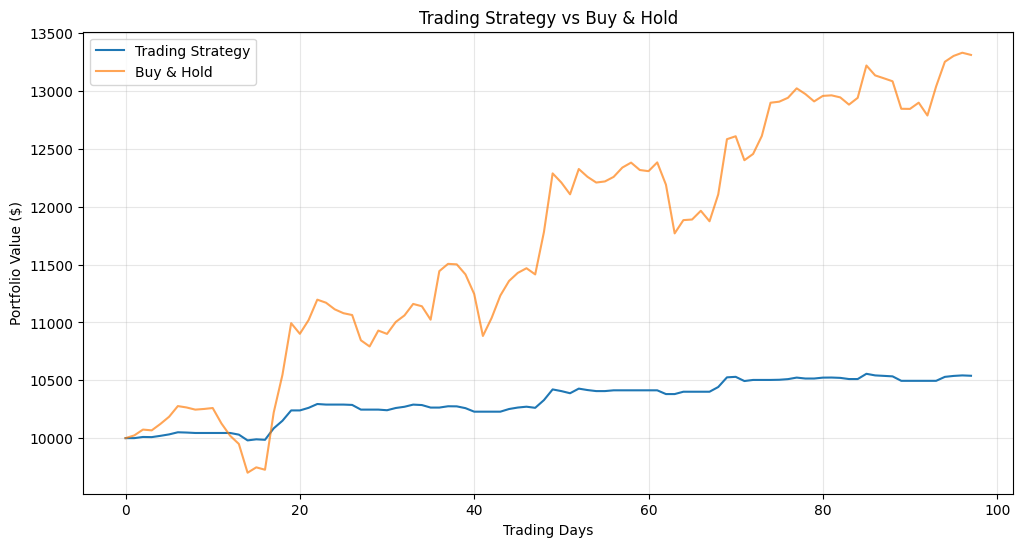


Dummy Classifier (always predict majority): 54.1%


In [42]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


def calculate_rsi(closes, period=14):
  pricechanges = closes.diff()
  gains = pricechanges.where(pricechanges > 0, 0)
  loss = -pricechanges.where(pricechanges < 0, 0)

  avggain = gains.rolling(window=period).mean()
  avgloss = loss.rolling(window=period).mean()


  rs = avggain / avgloss
  rsi = 100 - (100 / (1 + rs))
  return rsi


choice = input('Choose your stock to train on: ')
print(f'Downloading stock data of {choice}')
data = yf.download(choice, period='2y')

df = pd.DataFrame()
df['Close'] = data['Close']
df['Volume'] = data['Volume']

print('Calculating indicators')
df['RSI'] = calculate_rsi(df['Close'])
df['PgChange'] = df['Close'].pct_change()
df['Volume Ratio'] = df['Volume'] / df['Volume'].rolling(5).mean()

#create trading indicators
df['RSI OVERSOLD'] = (df['RSI'] < 30).astype(int)
df['RSI OVERBOUGHT'] = (df['RSI'] > 70).astype(int)
df['HIGH VOL'] = (df['Volume Ratio'] > 1.5).astype(int)

df['Tmr Up'] = (df['Close'].shift(-1) > df['Close']).astype(int)

df = df.dropna()

features = ['RSI', 'PgChange', 'Volume Ratio', 'RSI OVERSOLD', 'RSI OVERBOUGHT', 'HIGH VOL']
X = df[features]
y = df['Tmr Up']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, shuffle=False)

print('Training...')
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print(f'\nModel Accuracy: {accuracy:.1%}')

print('\nFeature Importance')
feature_names = features
importances = model.feature_importances_

for name, importance in zip(feature_names, importances):
  print(f'{name}: {importance:.1%}')

def simulation(model, X_test, prices, initial=10000):
  cash = initial
  shares = 0
  trades = []
  portfolio = []

  for i in range(len(X_test)):
    currentf = X_test.iloc[i:i+1]
    currentclose = float(prices.iloc[i])

    prediction = model.predict(currentf)[0]
    probability = model.predict_proba(currentf)[0][1]

    if probability > 0.55 and shares == 0:
      sharestobuy = (cash*0.2) / currentclose
      cash -= sharestobuy*currentclose
      shares += sharestobuy
      trades.append(f'BOUGHT {sharestobuy} SHARES AT ${currentclose}, USING ${sharestobuy*currentclose}')
    elif probability < 0.45 and shares > 0:
      cash += shares*currentclose
      trades.append(f'SOLD {shares} SHARES AT ${currentclose} GAINING ${shares*currentclose}')
      shares = 0
    portfolio.append(cash + shares*currentclose)

  return portfolio, trades


test_indices = X_test.index
test_prices = df.loc[test_indices, 'Close']
portfolio, trades = simulation(model, X_test, test_prices)

initial_cash = 10000
profit = portfolio[-1] - initial_cash
profit_percentage = (profit / initial_cash) * 100

print(f"\n=== TRADING RESULTS ===")
print(f"Starting: ${initial_cash:,.2f}")
print(f"Final: ${portfolio[-1]:,.2f}")
print(f"Profit: ${profit:,.2f} ({profit_percentage:.1f}%)")
print(f"Number of trades: {len(trades)}")

buy_hold_value = initial_cash * (test_prices.iloc[-1] / test_prices.iloc[0])
buy_hold_profit = buy_hold_value - initial_cash
print(f"Buy & Hold: ${buy_hold_value:,.2f} (${buy_hold_profit:,.2f})")



plt.figure(figsize=(12, 6))
plt.plot(portfolio, label='Trading Strategy')
plt.plot([initial_cash * (p / test_prices.iloc[0]) for p in test_prices],
         label='Buy & Hold', alpha=0.7)
plt.title('Trading Strategy vs Buy & Hold')
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Trading Days')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()






# Test for random prediction
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_accuracy = dummy.score(X_test, y_test)
print(f"\nDummy Classifier (always predict majority): {dummy_accuracy:.1%}")
